In [1]:
from datetime import datetime

# U.S. Industry ETFs
us_industry_etfs = {
    "XLF": "Financials",                # Financial Select Sector SPDR Fund
    "XLK": "Technology",                # Technology Select Sector SPDR Fund
    "XLE": "Energy",                    # Energy Select Sector SPDR Fund
    "XLI": "Industrials",               # Industrial Select Sector SPDR Fund
    "XLU": "Utilities",                 # Utilities Select Sector SPDR Fund
    "XLP": "Consumer Staples",          # Consumer Staples Select Sector SPDR Fund
    "XLY": "Consumer Discretionary",    # Consumer Discretionary Select Sector SPDR Fund
    "XLV": "Health Care",               # Health Care Select Sector SPDR Fund
    "XLB": "Materials",                 # Materials Select Sector SPDR Fund
    "XLRE": "Real Estate"               # Real Estate Select Sector SPDR Fund
}

trading_days_in_year = 252
# Define the start and end dates for fetching the data
start_date = '1990-01-01'
end_date = datetime.today().strftime("%Y-%m-%d")

In [2]:
!pip install pandas yfinance matplotlib seaborn

In [3]:
import pandas as pd
import yfinance as yf
import matplotlib.pyplot as plt

returns_df = pd.DataFrame()

# Fetch daily returns for each ticker
for ticker, asset_class in us_industry_etfs.items():
    try:
        # Fetch historical data for the ticker
        data = yf.download(ticker)
        
        # Check if the data is empty
        if data.empty:
            print(f"No data found for ticker: {ticker}")
            continue
        
        # Calculate daily returns
        data['Daily Return'] = data['Adj Close'].pct_change()
        
        # Add the daily returns to the returns DataFrame
        data = data[['Daily Return']].rename(columns={'Daily Return': asset_class})
        if returns_df.empty:
            returns_df = data
        else:
            returns_df = returns_df.join(data, how='outer')
    except Exception as e:
        print(f"Failed for ticker: {ticker}")
        print(e)
        
# Drop the first row with NaN values
returns_df = returns_df.iloc[1:]
returns_df.to_csv("../data/historical-class-returns.csv")
# Display the first few rows of the returns DataFrame
returns_df.head()

[*********************100%%**********************]  1 of 1 completed
[*********************100%%**********************]  1 of 1 completed
[*********************100%%**********************]  1 of 1 completed
[*********************100%%**********************]  1 of 1 completed
[*********************100%%**********************]  1 of 1 completed
[*********************100%%**********************]  1 of 1 completed
[*********************100%%**********************]  1 of 1 completed
[*********************100%%**********************]  1 of 1 completed
[*********************100%%**********************]  1 of 1 completed
[*********************100%%**********************]  1 of 1 completed


,Financials,Technology,Energy,Industrials,Utilities,Consumer Staples,Consumer Discretionary,Health Care,Materials,Real Estate
Date,,,,,,,,,,
1998-12-23,0.014745,0.023890,0.020819,0.017450,-0.004191,0.024175,0.004295,0.022472,0.010502,NaN
1998-12-24,0.006605,-0.003809,-0.005263,0.013193,0.018412,-0.001727,0.018326,0.006105,0.023014,NaN
1998-12-28,-0.013123,0.002868,-0.005291,0.005208,-0.005166,-0.005767,-0.008998,-0.014564,-0.008708,NaN
1998-12-29,0.010639,0.002860,0.009974,0.014249,0.016615,0.022041,0.021792,0.022168,0.018301,NaN
1998-12-30,-0.003948,-0.003803,-0.015142,-0.004469,-0.008171,-0.006243,-0.008294,-0.008434,-0.002876,NaN


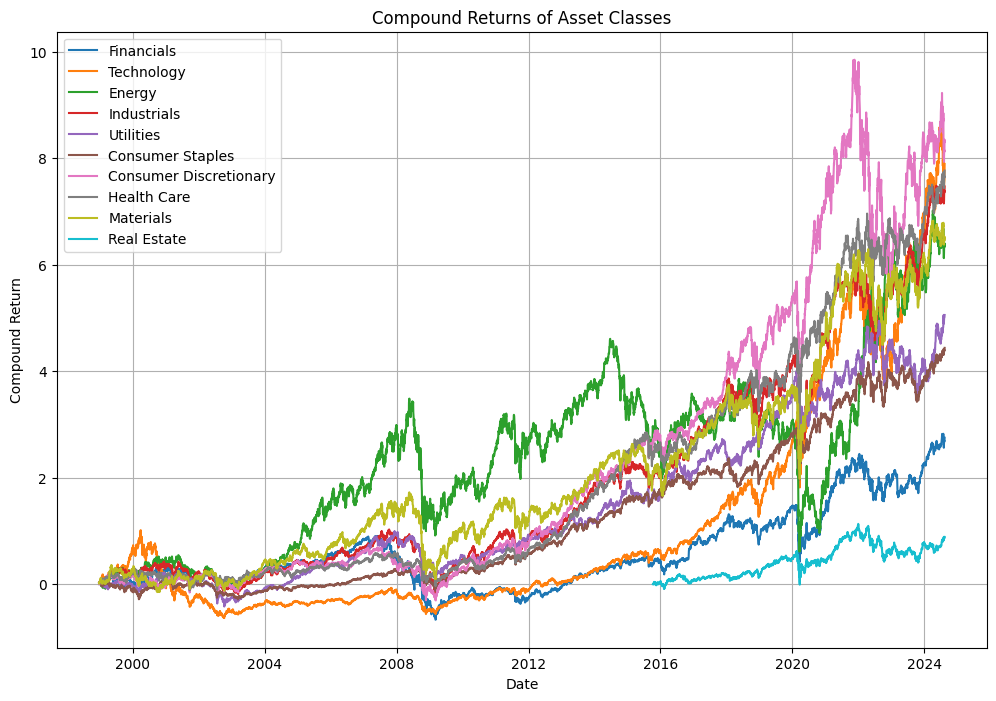

In [4]:
# Calculate compound returns
compound_returns = (1 + returns_df).cumprod() - 1

# Plot the compound returns
plt.figure(figsize=(12, 8))
for column in compound_returns.columns:
    plt.plot(compound_returns.index, compound_returns[column], label=column)

plt.title('Compound Returns of Asset Classes')
plt.ylabel('Compound Return')
plt.xlabel('Date')
plt.legend()
plt.grid(True)
plt.show()

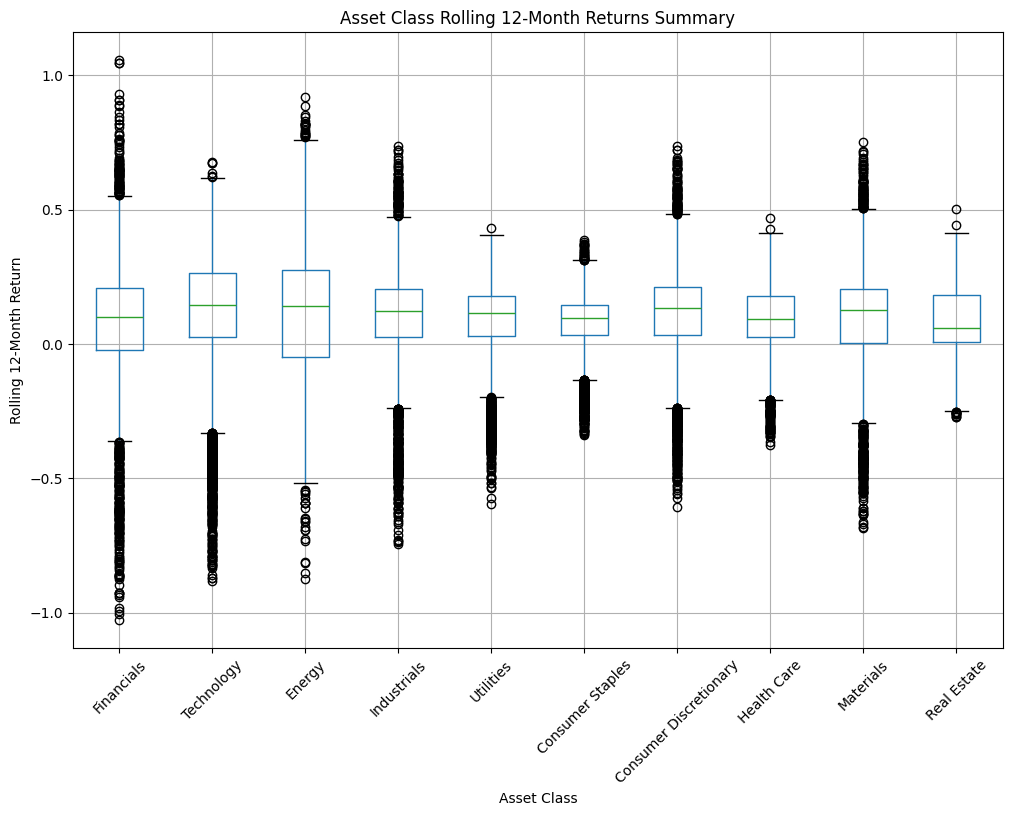

In [5]:
# Calculate 12-month rolling returns
rolling_returns = returns_df.rolling(window=trading_days_in_year).sum()  # 252 trading days in a year

# Plot the box and whisker chart for rolling 12-month returns
plt.figure(figsize=(12, 8))
rolling_returns.boxplot()
plt.title('Asset Class Rolling 12-Month Returns Summary')
plt.ylabel('Rolling 12-Month Return')
plt.xlabel('Asset Class')
plt.xticks(rotation=45)
plt.grid(True)
plt.show()

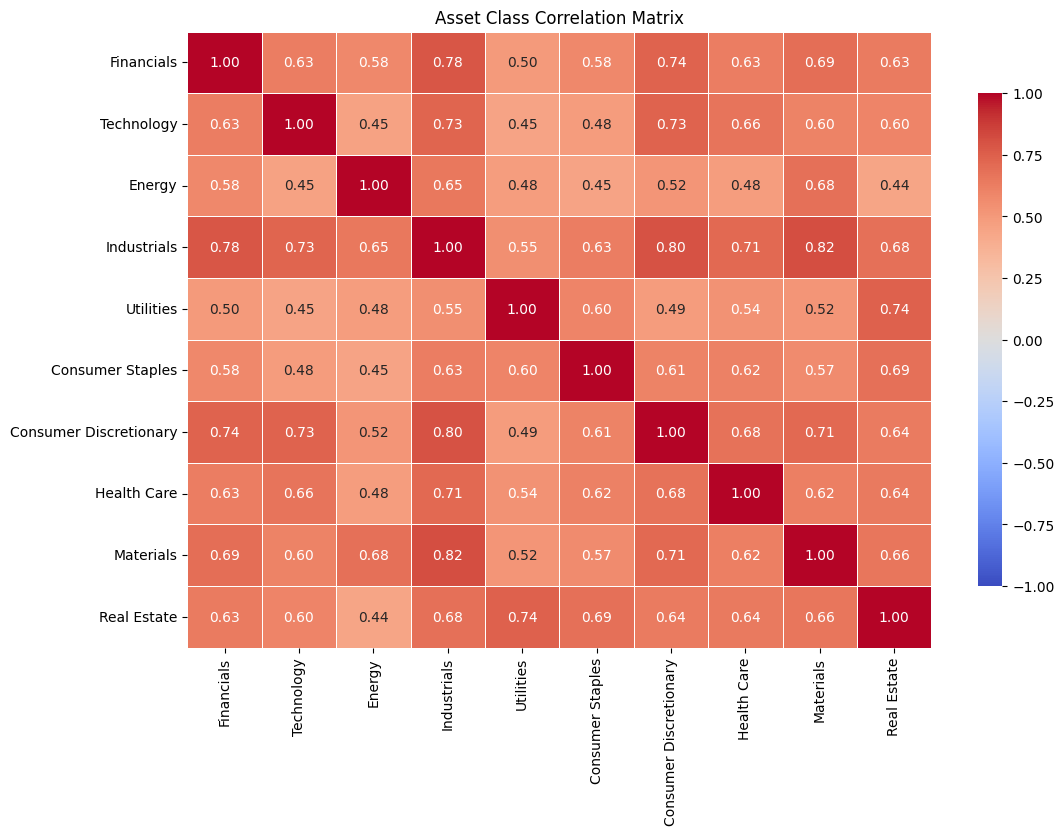

In [6]:
import seaborn as sns

# Calculate the correlation matrix of the daily returns
correlation_matrix = returns_df.corr()

# Plot the correlation matrix using a heatmap
plt.figure(figsize=(12, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', vmin=-1, vmax=1, center=0, 
            linewidths=0.5, fmt='.2f', cbar_kws={"shrink": .8})
plt.title('Asset Class Correlation Matrix')
plt.show()


Now let's compare performance of an equal contribution portfolio against a mean-variance optimized one, rebalancing on a quarterly basis

mean_returns_filtered: Financials                0.075624
Technology                0.491042
Energy                    0.250540
Industrials               0.173614
Utilities                -0.008892
Consumer Staples          0.007902
Consumer Discretionary    0.043745
Health Care               0.150211
Materials                 0.009984
dtype: float64
cov_matrix_filtered:                         Financials  Technology    Energy  Industrials  \
Financials                0.096475    0.039193  0.018120     0.038462   
Technology                0.039193    0.109944  0.006890     0.031438   
Energy                    0.018120    0.006890  0.067306     0.017352   
Industrials               0.038462    0.031438  0.017352     0.045322   
Utilities                 0.029661    0.017207  0.017595     0.018518   
Consumer Staples          0.039739    0.018021  0.012822     0.024585   
Consumer Discretionary    0.053537    0.036378  0.015150     0.035527   
Health Care               0.038449    0.04

/tmp/ipykernel_21287/2660116345.py:193: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  stored_weights_filled = stored_weights_shifted.ffill().fillna(0)


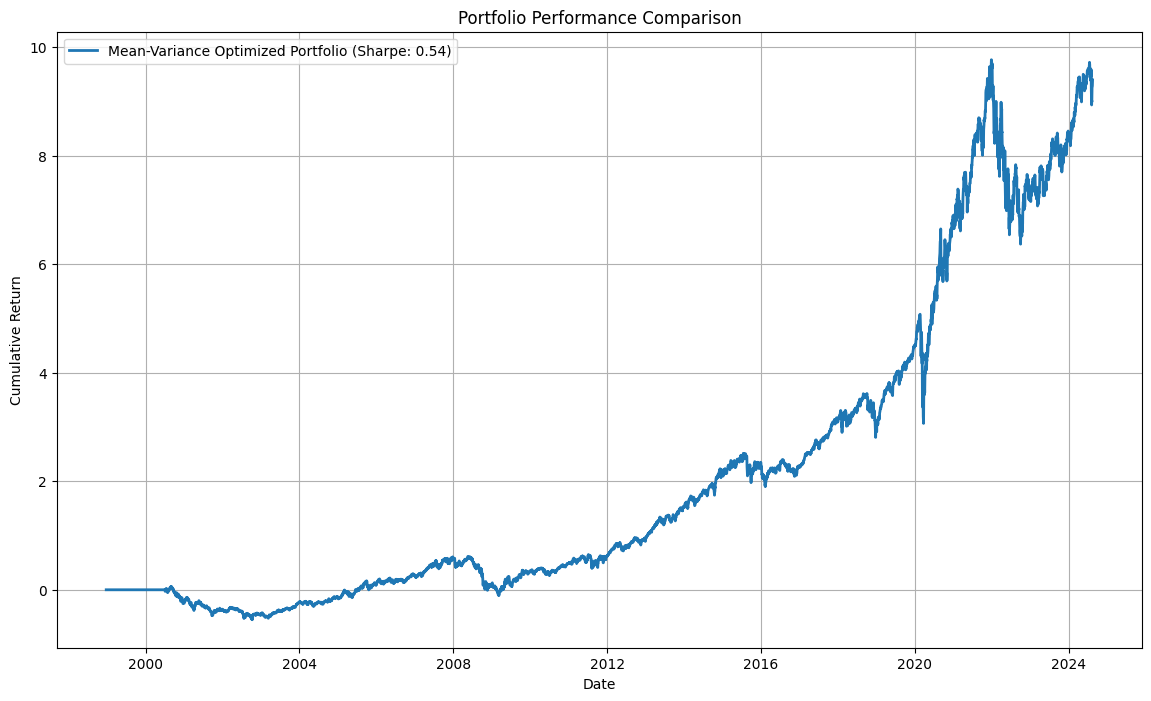

In [52]:
import pandas as pd
import numpy as np
import yfinance as yf
import matplotlib.pyplot as plt
from scipy.optimize import minimize

# Define the function for downloading the data
def download_data(tickers, start_date, end_date):
    data = yf.download(tickers, start=start_date, end=end_date)['Adj Close']
    return data


from scipy.optimize import minimize
import numpy as np
import pandas as pd

annualized_factor_from_freq = {"daily": 252, "monthly": 12, "quarterly": 4, "yearly": 1}


def get_valid_assets(returns):
    # Remove columns where all values are NaN
    non_nan_assets = returns.dropna(axis=1, how='all')
    
    # Remove columns where all remaining values are 0
    cleaned_ret = non_nan_assets.loc[:, (non_nan_assets != 0).any()]
    
    # Return list of valid asset names
    return list(cleaned_ret.columns)
    
def equal_contribution_weights(returns):
    assets = get_valid_assets(returns=returns)
    num_assets = len(assets)
    
    # Create a Series with equal weights for valid assets only
    weights = pd.Series(1. / num_assets, index=assets)
    
    # Ensure that all columns are represented, including non-valid assets with weight 0
    full_weights = pd.Series(0., index=returns.columns)
    full_weights[assets] = weights
    
    return full_weights

def annualized_expected_return(returns, frequency="daily"):
    assert frequency in annualized_factor_from_freq
    annual_factor = annualized_factor_from_freq[frequency]
    ann_return = (1 + returns.mean()) ** annual_factor - 1
    return ann_return

def annualized_volatility(returns, frequency="daily"):
    assert frequency in annualized_factor_from_freq
    annual_factor = annualized_factor_from_freq[frequency]
    ann_vol = returns.std() * np.sqrt(annual_factor)
    return ann_vol

def portfolio_return_from_weights(weights, mean_returns):
    return np.dot(weights, mean_returns)

def portfolio_volatility_from_weights(weights, cov_matrix):
    return np.sqrt(np.dot(weights.T, np.dot(cov_matrix, weights)))

def sharpe_ratio(expected_return, volatility_return, risk_free_rate=0.01):
    return (expected_return - risk_free_rate) / volatility_return

def get_valid_assets(returns):
    # Remove columns where all values are NaN
    non_nan_assets = returns.dropna(axis=1, how='all')
    
    # Remove columns where all remaining values are 0
    cleaned_ret = non_nan_assets.loc[:, (non_nan_assets != 0).any()]
    
    # Return list of valid asset names
    return list(cleaned_ret.columns)

def portfolio_optimization(returns, frequency, goal='minVol', risk_free_rate=0.01):
    annual_factor = annualized_factor_from_freq[frequency]
    
    # Get mean returns and covariance matrix up to the given date
    mean_returns = annualized_expected_return(returns=returns)
    cov_matrix = returns.cov() * annual_factor

    # Identify valid assets (non-NaN or non-zero returns)
    valid_assets = get_valid_assets(returns=returns)
    num_assets = len(valid_assets)
    # print("Valid Assets:", valid_assets)
    # If there are no valid assets left after cleaning
    if not num_assets:
        return pd.Series(index=mean_returns.index, dtype=float).fillna(0)

    # Filter returns and covariance matrix to include only valid assets
    mean_returns_filtered = mean_returns[valid_assets]
    cov_matrix_filtered = cov_matrix.loc[valid_assets, valid_assets]
    
    # Constraints and bounds for the optimization
    constraints = ({'type': 'eq', 'fun': lambda x: np.sum(x) - 1})
    bounds = tuple((0, 1) for _ in range(num_assets))
    initial_guess = num_assets * [1. / num_assets]
    
    print("mean_returns_filtered:", mean_returns_filtered)
    print("cov_matrix_filtered:", cov_matrix_filtered)
    def sharpe_helper(w, mean_returns, cov_matrix, risk_free_rate):
        expected_return = portfolio_return_from_weights(weights=w, mean_returns=mean_returns)
        volatility_return = portfolio_volatility_from_weights(weights=w, cov_matrix=cov_matrix)
        # print("Expected Return:", expected_return)
        # print("Volatility Return:", volatility_return)
        return sharpe_ratio(
            expected_return=expected_return,
            volatility_return=volatility_return,
            risk_free_rate=risk_free_rate
        )
    if goal == "minVol":
        f = lambda w: portfolio_volatility_from_weights(weights=w, cov_matrix=cov_matrix_filtered)
    elif goal == 'maxSharpe':
        f = lambda w: - sharpe_helper(w=w, mean_returns=mean_returns_filtered, 
                                    cov_matrix=cov_matrix_filtered, 
                                    risk_free_rate=risk_free_rate)
    else:
        raise ValueError("Invalid goal specified. Use 'minVol' or 'maxSharpe'.")

    result = minimize(f, initial_guess, method='SLSQP', bounds=bounds, constraints=constraints)

    if result.success:
        optimized_weights = pd.Series(result.x, index=valid_assets)
    else:
        raise ValueError("Optimization did not converge")
    
    # Assign weights for valid assets
    final_weights = pd.Series(index=mean_returns.index, dtype=float).fillna(0)
    final_weights.loc[valid_assets] = optimized_weights
    
    return final_weights

def calculate_portfolio_return(weights, returns):
    return np.dot(weights.fillna(0), returns.fillna(0))

def compute_weighted_returns(weights, returns):
    # Function to calculate portfolio return for a given date
    def calc_portfolio_return(date):
        w = weights.loc[date]
        returns_today = returns.loc[date]
        portfolio_return = calculate_portfolio_return(w, returns_today)
        return portfolio_return
        
    # Map the function to calculate portfolio returns
    portfolio_returns = returns.index.to_series().map(calc_portfolio_return)
    # Convert portfolio_returns to a Series with the same index
    portfolio_returns = pd.Series(portfolio_returns.values, index=returns.index)
    return portfolio_returns

def portfolio_allocation(returns, 
                          method='minVol', # 'eqCont', 'maxSharpe'
                          rebalance_freq='Q', 
                          frequency='daily', 
                          skip_first_n_periods=365, # Skip first n days to avoid sensitive mean annualized returns
                          lookback_period=1095, # 3Y Lookback
                          risk_free_rate=0.01):
    # rebalanace freq: M, Q, A for monthly, quarterly, and annualy
    # Create DataFrames for storing results
    stored_weights = pd.DataFrame(index=returns.index, columns=returns.columns)
    portfolio_returns = pd.Series(index=returns.index)
    assert frequency in annualized_factor_from_freq
    
    # Function to compute weights for a given date
    def compute_weights(date):
        end_date = date
        start_date = end_date - pd.Timedelta(days=lookback_period)
        
        # Ensure that we're skipping the first n periods
        if end_date <= returns.index[skip_first_n_periods]:
            return
        
        # Restrict returns to the lookback period
        lookback_returns = returns.loc[start_date:end_date]
        
        try:
            if method == 'minVol':
                weights = portfolio_optimization(returns=lookback_returns, frequency=frequency, goal=method)
            elif method == 'eqCont':
                weights = equal_contribution_weights(returns=lookback_returns)
            elif method == 'maxSharpe':
                weights = portfolio_optimization(returns=lookback_returns, frequency=frequency, goal=method)
            stored_weights.loc[date] = weights
        except ValueError as e:
            print(f"Error in optimization for date {date}: {e}")
            stored_weights.loc[date] = pd.Series(np.nan, index=returns.columns)
    
    # Compute weights for all rebalance dates
    rebalance_dates = returns.index.to_series().to_period(rebalance_freq).to_timestamp(rebalance_freq).sort_index().index.drop_duplicates()
    # print("Rebalance Dates:", rebalance_dates)
    rebalance_dates.map(compute_weights)

    # Shift weights to align with future returns and forward fill
    stored_weights_shifted = stored_weights.shift(1)
    stored_weights_filled = stored_weights_shifted.ffill().fillna(0)
    # print(f"Stored Weights:\n{stored_weights}")
    # print(f"Stored Weights Shifted:\n{stored_weights_shifted}")
    # print(f"Stored Weights Filled:\n{stored_weights_filled.iloc}")
    portfolio_returns = compute_weighted_returns(weights=stored_weights_filled, returns=returns)
    return portfolio_returns

import pandas as pd

def portfolio_performance(portfolio_returns: pd.Series, frequency: str = "daily", risk_free_rate: float = 0.01):
    # Calculate cumulative portfolio returns
    portfolio_returns_cum = (1 + portfolio_returns).cumprod() - 1
    
    # Calculate annualized expected return
    optimized_ann_return = annualized_expected_return(returns=portfolio_returns, frequency=frequency)
    
    # Calculate annualized volatility
    optimized_vol = annualized_volatility(returns=portfolio_returns, frequency=frequency)
    
    # Calculate Sharpe Ratio
    optimized_sharpe = sharpe_ratio(expected_return=optimized_ann_return, 
                                    volatility_return=optimized_vol, 
                                    risk_free_rate=risk_free_rate)
    
    # Return a dictionary with all calculated values
    performance_metrics = {
        "cumulative_returns": portfolio_returns_cum,
        "annualized_return": optimized_ann_return,
        "annualized_volatility": optimized_vol,
        "sharpe_ratio": optimized_sharpe,
        "portfolio_returns": portfolio_returns
    }
    
    return performance_metrics

# Define the plotting function
def plot_portfolio_performance(portfolio_cum, sharpe):
    plt.figure(figsize=(14, 8))
    # plt.plot(equal_contrib_portfolio_cum, label=f'Equal Contribution Portfolio (Sharpe: {equal_contrib_sharpe:.2f})', linewidth=2)
    plt.plot(portfolio_cum, label=f'Mean-Variance Optimized Portfolio (Sharpe: {sharpe:.2f})', linewidth=2)
    plt.title('Portfolio Performance Comparison')
    plt.xlabel('Date')
    plt.ylabel('Cumulative Return')
    plt.legend()
    plt.grid(True)
    plt.show()

# start_date = "2010-01-01"
# end_date = "2023-12-31"

# # Calculate portfolio performance
#  optimized_vol, optimized_sharpe = portfolio_performance(data, tickers)
monthly_returns_df = (1 + returns_df).resample('ME').prod() - 1
# portfolio_returns = portfolio_allocation(returns_df, frequency='daily', method='eqCont')
# portfolio_returns = portfolio_allocation(returns_df, frequency='daily', method='minVol')
portfolio_returns = portfolio_allocation(returns_df, frequency='daily', method='maxSharpe')

post_processing = portfolio_performance(portfolio_returns=portfolio_returns, frequency="daily")
# Plot the performance
plot_portfolio_performance(portfolio_cum=post_processing["cumulative_returns"], sharpe=post_processing["sharpe_ratio"])